# Лабораторная работа №1

«Анализ и прогнозирование временных рядов на примере розничных продаж»

Данные: `retail_sales_mock_data.csv`. 

Ниже разбираю ряд по шагам. После расчёта коротко пишу, что получилось.

In [100]:
import sys

import pandas as pd
from IPython.display import display

warnings.simplefilter("ignore")


In [101]:

df = (
    pd.read_csv("retail_sales_mock_data.csv", parse_dates=["Date"])
    .sort_values("Date")
    .set_index("Date")
    .asfreq("MS")
)

print("Файл:", data_path.resolve())
print("Наблюдений:", len(df))
print("Период:", df.index.min().date(), "—", df.index.max().date())
print("Частота:", df.index.freq)
display(df.head())

Файл: /Users/dmitry/Desktop/project/predective_analytic/lab1/retail_sales_mock_data.csv
Наблюдений: 48
Период: 2020-01-01 — 2023-12-01
Частота: <MonthBegin>


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


В файле 48 месяцев, с января 2020 по декабрь 2023, шаг ровно месяц, дыр в датах нет. Смотрю `SalesAmount`. Рядом два признака, `Promotion` и `HolidayMonth`. Ряд короткий, всего четыре года.

In [102]:
missing = df.isna().sum().rename("пропуски")
n_duplicate_dates = int(df.index.duplicated().sum())

december = pd.Series(df.index.month == 12, index=df.index).astype(int)
holiday_is_december = bool((df["HolidayMonth"] == december).all())

yearly_mean = df["SalesAmount"].resample("YS").mean().rename("средние продажи")
promo_months = df.index[df["Promotion"].eq(1)]

display(missing.to_frame())
print("Дубликаты дат:", n_duplicate_dates)
print("HolidayMonth совпадает с декабрём во всех точках:", holiday_is_december)
print("Месяцев с акцией:", int(df["Promotion"].sum()), "из", len(df))
print("Даты акций:", ", ".join(ts.strftime("%Y-%m") for ts in promo_months))
display(df["SalesAmount"].describe().to_frame("SalesAmount"))
display(yearly_mean.to_frame())

,пропуски
SalesAmount,0
Promotion,0
HolidayMonth,0


Дубликаты дат: 0
HolidayMonth совпадает с декабрём во всех точках: True
Месяцев с акцией: 6 из 48
Даты акций: 2020-04, 2020-06, 2020-10, 2021-05, 2022-01, 2023-05


,SalesAmount
count,48.000000
mean,11768.541667
std,2257.544863
min,7783.000000
25%,10219.750000
50%,11851.000000
75%,13014.000000
max,17996.000000


,средние продажи
Date,
2020-01-01,11422.250000
2021-01-01,11088.000000
2022-01-01,12025.333333
2023-01-01,12538.583333


Пропусков и повторных дат нет, статистики считаются по всем 48 месяцам.

Продажи от 7 783 до 17 996, среднее около 11 769. По годам: 2020 — 11 422, 2021 — 11 088, 2022 — 12 025, 2023 — 12 539. В 2021 среднее даже чуть ниже, чем в 2020, выше уровень становится в 2022–2023.

`HolidayMonth` равен 1 только в четырёх декабрях. Это пометка декабря, отдельного события там нет. В сезонной модели декабрь и так получит свой коэффициент, поэтому этот столбец в модель не кладу.

Акций шесть, месяцы разные: 2020-04, 2020-06, 2020-10, 2021-05, 2022-01, 2023-05. Они не сидят в одном и том же месяце каждый год, так что акцию можно отделить от сезона. Насколько она поднимает продажи, по средним пока не видно: акционные месяцы бывают и сильные, и слабые.

## График ряда

In [103]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 3.8)
plt.rcParams["axes.unicode_minus"] = False

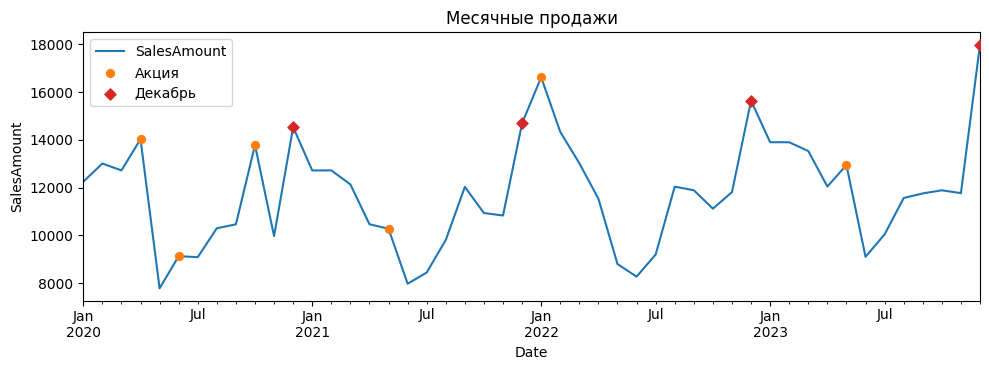

In [104]:
ax = df["SalesAmount"].plot(title="Месячные продажи", ylabel="SalesAmount")

promo = df["Promotion"].eq(1)
holiday = df["HolidayMonth"].eq(1)
ax.scatter(df.index[promo], df.loc[promo, "SalesAmount"], color="C1", s=32, zorder=3, label="Акция")
ax.scatter(df.index[holiday], df.loc[holiday, "SalesAmount"], color="C3", marker="D", s=32, zorder=3, label="Декабрь")
ax.legend()
plt.tight_layout()
plt.show()

На графике каждый год похож: к маю–июлю продажи падают, в декабре максимум. 2022–2023 в целом выше, чем 2020–2021, но 2021 чуть ниже 2020, так что это не прямая вверх.

Оранжевые точки — акции. Они есть и в сильном январе 2022, и в слабых месяцах, по одному графику их эффект от сезона не отделить. Красные ромбы — декабри. Здесь праздник и сезонный пик совпадают.

## Форма года

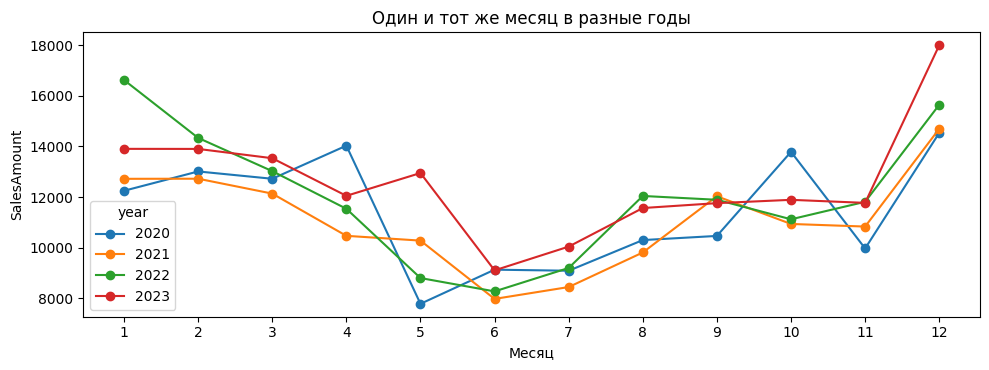

In [105]:
profile = df["SalesAmount"].to_frame()
profile["month"] = profile.index.month
profile["year"] = profile.index.year

profile.pivot(index="month", columns="year", values="SalesAmount").plot(marker="o")
plt.title("Один и тот же месяц в разные годы")
plt.xlabel("Месяц")
plt.ylabel("SalesAmount")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Форма года во всех четырёх годах одна: провал в мае–июле, декабрь выше остальных месяцев. Сам пик растёт: 14 534, 14 696, 15 645, 17 996.

Из этой формы выбиваются январь 2022 и май 2023, оба с акцией. Сезон есть, но часть всплесков совпадает с `Promotion`.

## Разброс по месяцам

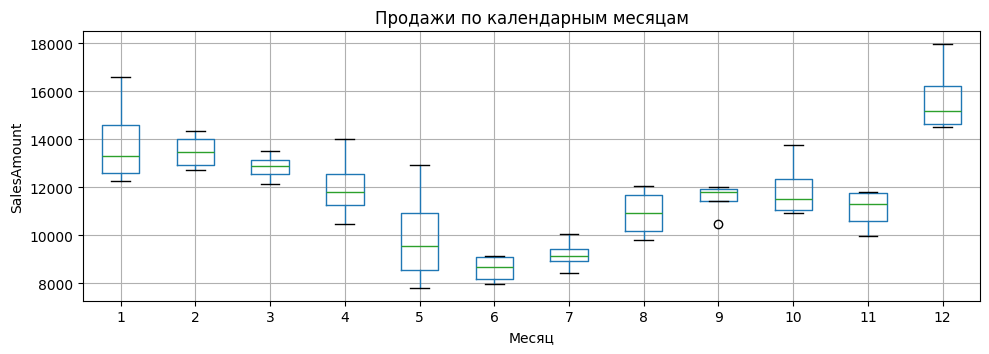

In [106]:
df.assign(month=df.index.month).boxplot(column="SalesAmount", by="month")
plt.suptitle("")
plt.title("Продажи по календарным месяцам")
plt.xlabel("Месяц")
plt.ylabel("SalesAmount")
plt.tight_layout()
plt.show()

На каждый месяц всего четыре точки, ящик грубый. Картина та же, что на линиях: май–июль ниже, декабрь выше и разброс шире. Широкий декабрьский ящик — это рост пика по годам, а не разброс вокруг одного уровня.

## Скользящее среднее

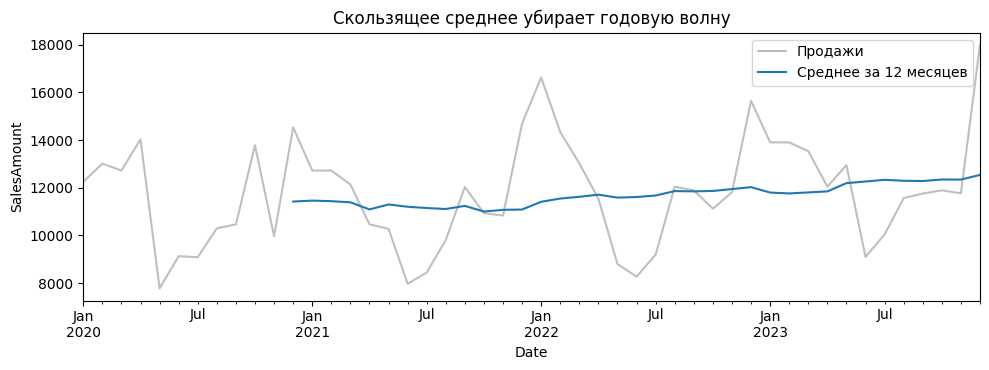

In [107]:
level = df["SalesAmount"].rolling(12).mean()

ax = df["SalesAmount"].plot(color="0.75", label="Продажи")
level.plot(ax=ax, label="Среднее за 12 месяцев")
ax.set_title("Скользящее среднее убирает годовую волну")
ax.set_ylabel("SalesAmount")
ax.legend()
plt.tight_layout()
plt.show()

Среднее за 12 месяцев убирает декабрьские пики и летние провалы. К декабрю 2021 оно равно 11 088, к декабрю 2023 — 12 539. Уровень сдвинулся после 2021, но годовая волна больше этого сдвига: от лета до декабря продажи меняются сильнее, чем за два года роста.

Для разложения отсюда беру сезон с периодом 12 и слабый тренд. Основное колебание — сезон.

## Классическая декомпозиция

Период беру 12, так выглядит годовая волна на графиках. Две формы одной схемы: аддитивная складывает, мультипликативная перемножает. У обеих сезон каждый год одинаковый, тренд на краях не определён.

In [108]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [109]:
add = seasonal_decompose(df["SalesAmount"], model="additive", period=12)

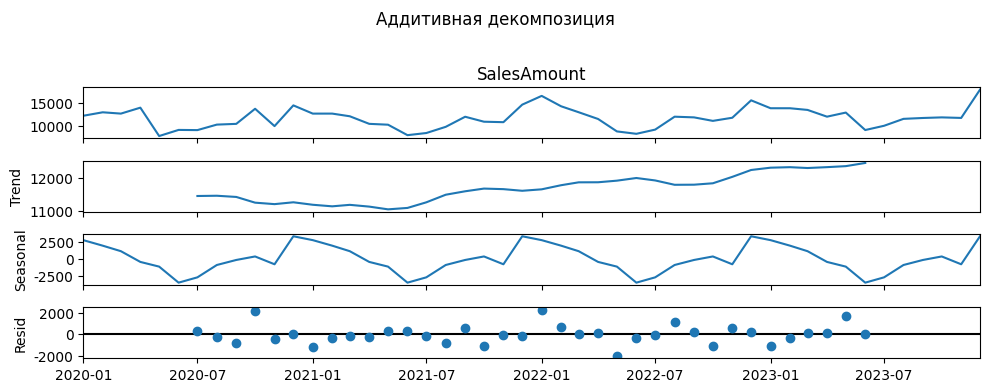

In [110]:
add.plot()
plt.suptitle("Аддитивная декомпозиция", y=1.02)
plt.tight_layout()
plt.show()

In [111]:
add_month = add.seasonal.groupby(add.seasonal.index.month).first()
add_month.index.name = "месяц"
display(add_month.rename("сезон, ед.").to_frame().round(0))

,"сезон, ед."
месяц,
1,2698.0
2,1905.0
3,1113.0
4,-425.0
5,-1099.0
6,-3397.0
7,-2636.0
8,-865.0
9,-144.0


В аддитивной модели продажа = тренд + добавка месяца + остаток. Добавка одна на все годы: декабрь +3 253, у июня самый большой минус, −3 397.

Форма года с этим сходится, а рост декабря с 14 534 до 17 996 — нет. Средний уровень сдвинулся примерно на тысячу, фиксированные +3 253 этот рост не забирают, лишнее остаётся в остатке. На первых и последних шести месяцах тренда нет: скользящее среднее периода 12 съедает края.

In [112]:
mul = seasonal_decompose(df["SalesAmount"], model="multiplicative", period=12)

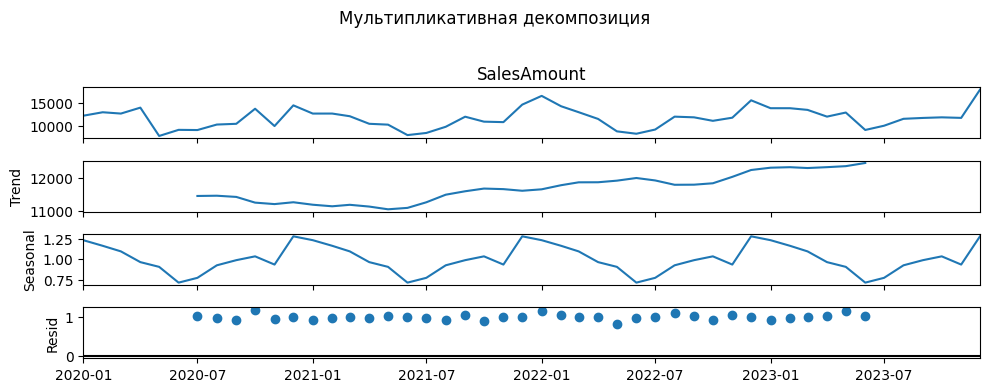

In [113]:
mul.plot()
plt.suptitle("Мультипликативная декомпозиция", y=1.02)
plt.tight_layout()
plt.show()

In [114]:
mul_month = mul.seasonal.groupby(mul.seasonal.index.month).first()
mul_month.index.name = "месяц"
display(mul_month.rename("сезонный множитель").to_frame().round(3))

,сезонный множитель
месяц,
1,1.231
2,1.163
3,1.094
4,0.963
5,0.906
6,0.713
7,0.772
8,0.925
9,0.987


В мультипликативной модели продажа = тренд × множитель месяца. Декабрь всегда в 1,278 раза выше тренда, июнь — в 0,713. Продажи положительные, делить можно.

Множитель тоже один на все годы. Декабрь 2023 равен 17 996 при среднем за год 12 539, пик вырос сильнее уровня, часть этого роста останется в остатке. Акции января 2022 и мая 2023 каждый год не повторяются, в сезонную форму они не входят.

In [115]:
y = df["SalesAmount"]
fit_add = (add.trend + add.seasonal).dropna()
fit_mul = (mul.trend * mul.seasonal).dropna()

recon = pd.Series({
    "аддитивная": ((y.loc[fit_add.index] - fit_add) ** 2).mean(),
    "мультипликативная": ((y.loc[fit_mul.index] - fit_mul) ** 2).mean(),
})
display(recon.rename("MSE восстановления").to_frame().round(0))

,MSE восстановления
аддитивная,738431.0
мультипликативная,748126.0


Остаток мультипликативной модели безразмерный и крутится около единицы, по нему модели не сравнить. Считаю MSE восстановления в исходных единицах продаж. Меньше MSE — ближе к ряду.

Аддитивная MSE 738 431, мультипликативная 748 126. Разница около 1%, сумма или произведение почти не важно. Обе модели считают, что сезон каждого года — копия прошлого. Для этих данных это грубо: декабрьский пик растёт быстрее уровня, а шесть акций не повторяют календарь. Это уходит в остаток. Края по полгода с каждой стороны в сравнении не участвуют, там тренда нет.

## Спектр, быстрое преобразование Фурье

Фурье ищет периоды сразу по всему ряду. Перед преобразованием убираю прямую, иначе почти вся мощность сядет на нулевой частоте, то есть на тренде.

In [116]:
import numpy as np
from scipy import signal

In [117]:
y_dt = signal.detrend(df["SalesAmount"].to_numpy(dtype=float))

In [118]:
n = len(y_dt)
freqs = np.fft.rfftfreq(n, d=1)
power = np.abs(np.fft.rfft(y_dt)) ** 2

periods = np.full(freqs.shape, np.nan)
nz = freqs > 0
periods[nz] = 1 / freqs[nz]

In [119]:
mask = (periods >= 2) & (periods <= 24)
spectrum = pd.DataFrame({"период, мес.": periods[mask], "мощность": power[mask]})
spectrum = spectrum.sort_values("мощность", ascending=False)
display(spectrum.head(5).round(1))

,"период, мес.",мощность
2,12.0,3.376921e+09
10,4.0,4.068245e+08
22,2.0,2.581354e+08
6,6.0,1.891419e+08
18,2.4,1.650044e+08


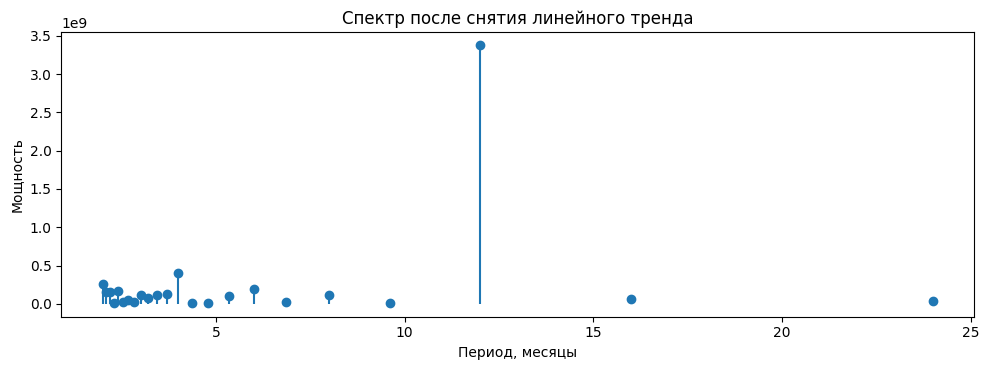

In [120]:
view = spectrum.sort_values("период, мес.")
plt.stem(view["период, мес."], view["мощность"], basefmt=" ")
plt.title("Спектр после снятия линейного тренда")
plt.xlabel("Период, месяцы")
plt.ylabel("Мощность")
plt.tight_layout()
plt.show()

На 48 месяцах шаг частоты равен 1/48, период 12 попадает ровно в одну корзину. Он главный: мощность около 3,4·10⁹, следующий пик (4 месяца) слабее примерно в восемь раз. Год в ряде есть.

Спектр один на все четыре года. Он не показывает, что декабрь из года в год выше: для Фурье это одна и та же волна. Акции не периодичны и своего пика не дают. Циклов всего четыре, соседние периоды получаются грубыми. Тренд я убрал заранее, само преобразование его от сезона не отделяет.

## Вейвлет Морле

Фурье дал период 12 сразу по всему ряду, без времени. Вейвлет Морле смотрит период и месяц вместе. Беру тот же ряд без прямой, что и для спектра.

Добеши на 48 точках даёт мало масштабов и не показывает, держится ли период. Поэтому беру Морле.

In [121]:
def morlet(n, scale, w=6.0):
    x = (np.arange(n) - (n - 1) / 2) / scale
    return np.exp(1j * w * x) * np.exp(-0.5 * x**2) * np.pi ** (-0.25)


def cwt_morlet(data, scales, w=6.0):
    data = np.asarray(data, dtype=float)
    out = np.empty((len(scales), len(data)), dtype=complex)
    for i, scale in enumerate(scales):
        width = max(int(min(10 * scale, len(data))), 1)
        wavelet = np.conj(morlet(width, scale, w)[::-1])
        out[i] = np.convolve(data, wavelet, mode="same")
    return out

In [122]:
w0 = 6.0
scales = np.arange(1, 25)
cwt = cwt_morlet(y_dt, scales, w=w0)
wave_periods = 2 * np.pi * scales / w0
power_w = np.abs(cwt) ** 2

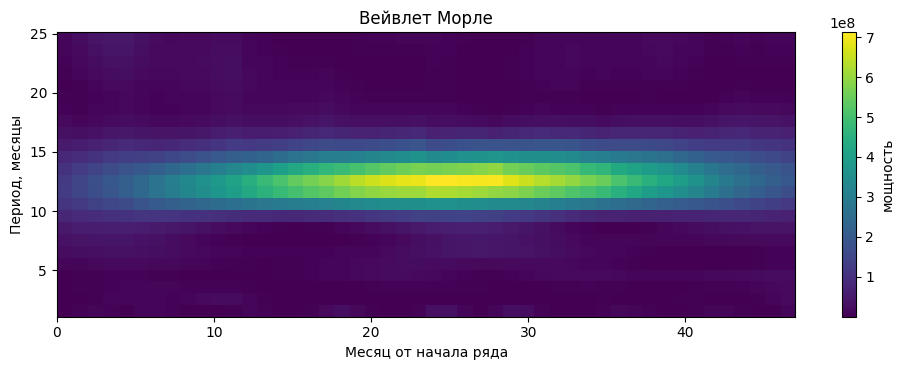

In [123]:
fig, ax = plt.subplots()
image = ax.imshow(
    power_w,
    aspect="auto",
    origin="lower",
    extent=[0, len(y_dt) - 1, wave_periods[0], wave_periods[-1]],
)
ax.set_title("Вейвлет Морле")
ax.set_xlabel("Месяц от начала ряда")
ax.set_ylabel("Период, месяцы")
fig.colorbar(image, ax=ax, label="мощность")
plt.tight_layout()
plt.show()

Яркая полоса — период, который силён в этот месяц. Она не рвётся и лежит около года. В следующей ячейке средний период получается 12,5 месяца, разброс 0,2. У Фурье это был один столбец на весь ряд, здесь видно, что полоса держится по времени.

In [124]:
band = (wave_periods >= 3) & (wave_periods <= 24)
band_power = np.where(band[:, None], power_w, 0.0)
dominant = wave_periods[band_power.argmax(axis=0)]
print("Средний доминирующий период, мес.:", round(float(dominant.mean()), 1))
print("Разброс по времени, мес.:", round(float(dominant.std()), 1))

Средний доминирующий период, мес.: 12.5
Разброс по времени, мес.: 0.2


В полосе от 3 до 24 месяцев средний доминирующий период 12,5 месяца, разброс 0,2. Другой период на смену году не приходит. Декабрьский пик на графиках при этом растёт: период стабильный, а размах сезона меняется.

На 48 точках вейвлет не точный сразу и по времени, и по периоду. Края картинки менее надёжны, чем середина.

**Вывод.** Классическая декомпозиция и Фурье видят один год на всём ряде: главный период спектра — 12 месяцев. Аддитивная форма чуть ближе к ряду, чем мультипликативная: MSE 738 431 против 748 126. Вейвлет показывает, что период около 12,5 держится всё время. Для прогноза беру сезонность 12. Одинаковый сезон каждый год получается грубо, потому что декабрьский пик вырос, но другого периода в ряде нет.

## Параметры прогноза

Из разложений беру период 12. Последние 12 месяцев откладываю: это один полный сезон, и на обучении остаётся три года. Порядки `p, q, P, Q` выбираю только по первым 36 месяцам.

In [125]:
from statsmodels.tsa.stattools import adfuller

In [126]:
horizon = 12
y_train = df["SalesAmount"].iloc[:-horizon]
print(y_train.index.min().date(), "—", y_train.index.max().date())
print("Обучение:", len(y_train), "месяцев")

2020-01-01 — 2022-12-01
Обучение: 36 месяцев


In [127]:
adf_level = adfuller(y_train, autolag="AIC")
adf_diff = adfuller(y_train.diff().dropna(), autolag="AIC")
print("Уровень, p-value:", round(adf_level[1], 4))
print("Первая разность, p-value:", round(adf_diff[1], 4))

Уровень, p-value: 0.0032
Первая разность, p-value: 0.0001


In [128]:
d = 0 if adf_level[1] < 0.05 else 1
D = 1
print("d =", d)
print("D =", D, ", m = 12")

d = 0
D = 1 , m = 12


На 36 обучающих месяцах тест Дики–Фуллера по уровню даёт p-value 0,0032, единичный корень отвергается, поэтому `d = 0`. Первая разность тоже стационарна (p-value 0,0001), лишний раз её брать не буду. Сезонную разность ставлю `D = 1`, `m = 12` по разложению: спектр и вейвлет дают год, период вейвлета 12,5 ± 0,2.

`HolidayMonth` в модель не кладу: это метка декабря, сезон и так даст декабрю свой коэффициент. `Promotion` оставляю для SARIMAX: шесть акций в разных месяцах, от годовой волны сами не отделяются.

## Порядок ARIMA

Несезонная модель — SARIMAX с `seasonal_order = (0, 0, 0, 0)`. Сезон и акцию сюда не кладу, их сравню отдельно на той же обучающей выборке.

In [129]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [130]:
def aic_row(order, seasonal_order, exog=None):
    
    model = SARIMAX(
        y_train,
        exog=exog,
        order=order,
        seasonal_order=seasonal_order,
        trend="c",  # при d = 0 среднее продаж не ноль
        enforce_stationarity=True,
        enforce_invertibility=True,
    )
    result = model.fit(disp=False, maxiter=200)
    if not result.mle_retvals.get("converged", False):
        return None
    return {"AIC": result.aic, "BIC": result.bic}

In [131]:
arima_rows = []
for p in range(3):
    for q in range(3):
        row = aic_row((p, d, q), (0, 0, 0, 0))
        if row is None:
            continue
        row["p"] = p
        row["q"] = q
        arima_rows.append(row)

arima_aic = pd.DataFrame(arima_rows).sort_values("AIC").reset_index(drop=True)
display(arima_aic.round(1))
print("Лучший порядок ARIMA:", (int(arima_aic.loc[0, "p"]), d, int(arima_aic.loc[0, "q"])))

,AIC,BIC,p,q
0,653.0,657.8,1,0
1,654.0,660.4,0,2
2,655.0,661.4,2,0
3,655.1,661.4,1,1
4,655.6,660.4,0,1
5,656.1,664.0,1,2
6,656.3,664.2,2,1
7,658.4,667.9,2,2
8,660.4,663.5,0,0


Лучший порядок ARIMA: (1, 0, 0)


С константой сошлись все девять порядков. Лучший AIC у ARIMA(1, 0, 0): 653,0, BIC тоже лучший, 657,8. Следующая модель (0, 0, 2) хуже по AIC всего на 1,0. Модель из одного среднего (0, 0, 0) имеет AIC 660,4, на 7,4 хуже. Константа держит уровень, AR(1) добавляет связь с прошлым месяцем.

Этот AIC с сезонным не сравниваю. После `D = 1` в правдоподобии на год меньше точек, шкала другая.

## Порядок SARIMAX

Сезонная разность `D = 1`, период 12. `P` и `Q` беру только 0 или 1: сезонный лаг 2 — это 24 месяца, а обучение 36, такой член почти нечем оценить. Несезонные `p` и `q` снова перебираю от 0 до 2: после сезонной разности порядок может смениться. Экзогенный признак — `Promotion` на обучающих месяцах. При сезонной разности константа — это средний прирост за год, а не уровень продаж.

In [132]:
arima_order = (int(arima_aic.loc[0, "p"]), d, int(arima_aic.loc[0, "q"]))
arima_order

(1, 0, 0)

In [133]:
promo_train = df.loc[y_train.index, "Promotion"]
sarimax_rows = []
for p in range(3):
    for q in range(3):
        for P in range(2):
            for Q in range(2):
                row = aic_row((p, d, q), (P, D, Q, 12), exog=promo_train)
                if row is None:
                    continue
                row["p"] = p
                row["q"] = q
                row["P"] = P
                row["Q"] = Q
                sarimax_rows.append(row)

sarimax_aic = pd.DataFrame(sarimax_rows).sort_values("AIC").reset_index(drop=True)
display(sarimax_aic.round(1).head(8))
print("Сошлось:", len(sarimax_aic), "из 36")
best = sarimax_aic.loc[0]
print(
    "Лучший порядок SARIMAX:",
    (int(best["p"]), d, int(best["q"])),
    (int(best["P"]), D, int(best["Q"]), 12),
)

,AIC,BIC,p,q,P,Q
0,388.8,394.7,0,1,0,1
1,388.8,394.7,0,0,1,1
2,388.9,394.7,1,0,0,1
3,389.1,395.0,0,1,1,0
4,390.8,397.9,2,0,0,1
5,390.8,397.9,0,1,1,1
6,390.9,398.0,0,2,0,1
7,390.9,398.0,1,1,0,1


Сошлось: 36 из 36
Лучший порядок SARIMAX: (0, 0, 1) (0, 1, 1, 12)


Сошлись все 36 моделей. Минимальный AIC 388,8 и BIC 394,7 сразу у трёх порядков, до одного знака после запятой они совпали: (0, 0, 1)(0, 1, 1, 12), (0, 0, 0)(1, 1, 1, 12) и (1, 0, 0)(0, 1, 1, 12). Параметров у каждой пять. Беру первую строку: SARIMAX(0, 0, 1)(0, 1, 1, 12) с акцией. У семи из восьми верхних строк `Q = 1`. Несезонный порядок сменился: у ARIMA был (1, 0, 0), здесь (0, 0, 1). После снятия года остаётся короткий шок.

388,8 и 653,0 сравнивать нельзя. После `D = 1` критерий считается по более короткому ряду.

## Прогноз на 12 месяцев

Порядок ARIMA — (1, 0, 0), SARIMAX — (0, 0, 1)(0, 1, 1, 12). Обе модели учу на 2020–2022. Акция 2023 уже стоит в данных: май равен 1, остальные месяцы — 0. В прогноз SARIMAX кладу этот календарь, акцию назначают заранее.

In [134]:
top = sarimax_aic.loc[0]
sarimax_order = (int(top["p"]), d, int(top["q"]))
sarimax_seasonal = (int(top["P"]), D, int(top["Q"]), 12)
sarimax_order, sarimax_seasonal

((0, 0, 1), (0, 1, 1, 12))

In [135]:
arima_res = SARIMAX(
    y_train,
    order=arima_order,
    seasonal_order=(0, 0, 0, 0),
    trend="c",
).fit(disp=False)
print("ARIMA AIC", round(arima_res.aic, 1), "BIC", round(arima_res.bic, 1))

ARIMA AIC 653.0 BIC 657.8


In [136]:
sarimax_res = SARIMAX(
    y_train,
    exog=promo_train,
    order=sarimax_order,
    seasonal_order=sarimax_seasonal,
    trend="c",
).fit(disp=False)
print("SARIMAX AIC", round(sarimax_res.aic, 1), "BIC", round(sarimax_res.bic, 1))
print(sarimax_res.params.round(1))

SARIMAX AIC 388.8 BIC 394.7
intercept      1000.4
Promotion      2624.6
ma.L1             0.0
ma.S.L12         -0.4
sigma2       387062.8
dtype: float64


In [137]:
y_test = df["SalesAmount"].iloc[-horizon:]
promo_test = df.loc[y_test.index, "Promotion"]

fc_arima = arima_res.get_forecast(horizon).predicted_mean
fc_sarimax = sarimax_res.get_forecast(horizon, exog=promo_test).predicted_mean

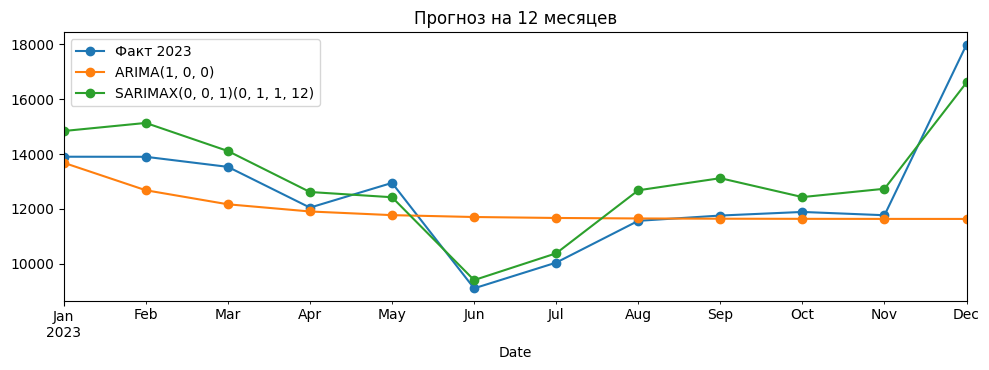

In [138]:
ax = y_test.plot(label="Факт 2023", marker="o")
fc_arima.plot(ax=ax, label=f"ARIMA{arima_order}", marker="o")
fc_sarimax.plot(ax=ax, label=f"SARIMAX{sarimax_order}{sarimax_seasonal}", marker="o")
ax.set_title("Прогноз на 12 месяцев")
ax.legend()
plt.tight_layout()
plt.show()

ARIMA снова дала AIC 653,0 и BIC 657,8, SARIMAX — 388,8 и 394,7, как в переборе. Константа 1 000 — средний прирост за год после сезонной разности. Коэффициент акции около 2 625: месяц с `Promotion = 1` выше остальной схемы примерно на эту величину. Несезонное MA на печати 0,0, сезонное −0,4. Короткий шок почти нулевой, год держит сезонная часть.

ARIMA(1, 0, 0) декабрьский пик не рисует, сезона в ней нет, прогноз идёт к среднему. SARIMAX повторяет форму прошлого года и поднимает май 2023, там акция. Оптимизатор написал предупреждение про число итераций, но AIC совпал с таблицей, оценка та же.

## Ошибка на отложенных месяцах

Обе модели выходят из декабря 2022. Горизонт 6 — январь–июнь 2023, горизонт 12 — весь отложенный год. Рядом сезонный наивный прогноз: продажа месяца равна продаже того же месяца год назад. Горизонт беру тот, где модель точнее наивного и R² больше нуля. Если оба подходят, оставляю более длинный.

In [139]:
from sklearn.metrics import mean_squared_error, r2_score

In [140]:
def forecast_scores(actual, pred):
    return {
        "MSE": mean_squared_error(actual, pred),
        "R2": r2_score(actual, pred),
    }

naive = df["SalesAmount"].shift(12)
rows = []
for h in (6, 12):
    actual = y_test.iloc[:h]
    preds = {
        "сезонный наивный": naive.loc[actual.index],
        "ARIMA": fc_arima.iloc[:h],
        "SARIMAX": fc_sarimax.iloc[:h],
    }
    for name, pred in preds.items():
        row = forecast_scores(actual, pred)
        row["горизонт"] = h
        row["модель"] = name
        rows.append(row)

scores = pd.DataFrame(rows)[["горизонт", "модель", "MSE", "R2"]]
scores["MSE"] = scores["MSE"].round(0)
scores["R2"] = scores["R2"].round(3)
display(scores)

,горизонт,модель,MSE,R2
0,6,сезонный наивный,4334865.0,-0.538
1,6,ARIMA,1927962.0,0.316
2,6,SARIMAX,571087.0,0.797
3,12,сезонный наивный,2757115.0,0.404
4,12,ARIMA,4565244.0,0.013
5,12,SARIMAX,815177.0,0.824


**Вывод.** На 6 месяцах обе модели лучше наивного прогноза, R² положительный. SARIMAX: MSE 571 087, R² 0,797. ARIMA: MSE 1 927 962, R² 0,316. Наивный: MSE 4 334 865, R² −0,538.

На 12 месяцах наивный уже ловит год: MSE 2 757 115, R² 0,404. ARIMA хуже него, MSE 4 565 244 и R² 0,013: сезона нет, декабрь она пропускает. SARIMAX лучше наивного: MSE 815 177, R² 0,824. На годе оба условия выполнены, поэтому горизонт беру 12 месяцев и модель SARIMAX. MSE у неё выше, чем на полугодии, но R² тоже выше.

AIC 653,0 и 388,8 сюда не подставляю. После `D = 1` они посчитаны по ряду другой длины.

## Остатки SARIMAX

Смотрю обучающие остатки модели, которая лучше на годе. Первые 12 месяцев отбрасываю: их съела сезонная разность `D = 1`. Нормальность — Шапиро–Уилк, точек меньше пятидесяти. Автокорреляция — Льюнг–Бокс на лагах 6 и 12 и график ACF. Одинаковый разброс — Бройш–Паган: квадрат остатка против подогнанного значения.

In [141]:
from scipy.stats import shapiro
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

In [142]:
burn = D * 12
resid = sarimax_res.resid.iloc[burn:]
fitted = sarimax_res.fittedvalues.iloc[burn:]
print("Остатков после сезонной разности:", len(resid))

Остатков после сезонной разности: 24


In [143]:
shapiro_stat, shapiro_p = shapiro(resid)
print("Шапиро–Уилк, p-value:", round(shapiro_p, 4))

Шапиро–Уилк, p-value: 0.2768


In [144]:
ljung = acorr_ljungbox(resid, lags=[6, 12], return_df=True)
display(ljung.round(4))

,lb_stat,lb_pvalue
6,5.8691,0.4380
12,11.8959,0.4541


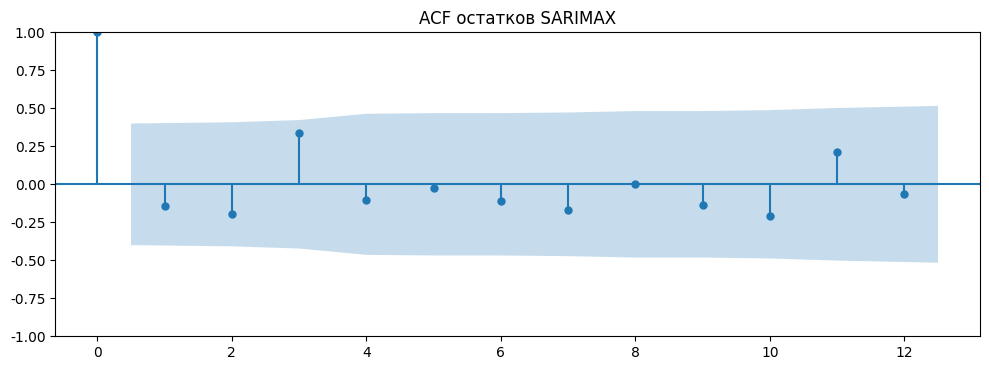

In [145]:
plot_acf(resid, lags=12, title="ACF остатков SARIMAX")
plt.tight_layout()
plt.show()

In [146]:
bp_exog = pd.DataFrame({"const": 1.0, "fitted": fitted.to_numpy()})
bp_stat, bp_p, _, _ = het_breuschpagan(resid, bp_exog)
print("Бройш–Паган, p-value:", round(bp_p, 4))

Бройш–Паган, p-value: 0.1086


После сезонной разности остаётся 24 точки. Шапиро–Уилк: p-value 0,2768, нормальность не отвергается. Льюнг–Бокс: 0,438 на лаге 6 и 0,454 на лаге 12, автокорреляции нет. Бройш–Паган: 0,1086, разброс от подогнанного значения не зависит. Это ближе всех к 0,05, но порог ещё не пробит. На обучении остаток похож на шум. Это 2020–2022, отложенный 2023 сюда не входит.

## Итог

**Вывод.** Беру SARIMAX(0, 0, 1)(0, 1, 1, 12) с константой и `Promotion`. Прогноз на 12 месяцев, весь 2023 год.

Порядок взял из разбора ряда. Спектр и вейвлет дают период около года, поэтому `D = 1` и `m = 12`. Дики–Фуллер на обучении не требует разности, `d = 0`. `HolidayMonth` не кладу: это метка декабря. Акция остаётся, коэффициент около 2 625.

На 2023 годе SARIMAX точнее наивного прогноза и ARIMA(1, 0, 0): MSE 815 177 против 2 757 115 и 4 565 244, R² 0,824. ARIMA лучше наивного только на первых шести месяцах. На полном годе декабрь ей нечем описать, ошибка самая большая. AIC 653,0 и 388,8 между собой не сравниваю: после сезонной разности точек в критерии меньше на год. Остатки SARIMAX на обучении нормальные, без автокорреляции, разброс от уровня не зависит.

Декабрьский пик вырос с 14 534 до 17 996, а сезон в модели повторяет прошлый год. Наивный прогноз этот рост пропускает. SARIMAX на 2023 всё равно ближе к факту. Ряд всего 48 месяцев, горизонт длиннее года уже не на чем проверить.